# Day 3 Final — Blind routing → DnCNN → USRNet

`corrupted → pixel-only noise classifier → noise-specific DnCNN → blind residual sigma → USRNet(actual dipole PSF) → restored`

Test inference reads image arrays only. Validation synthetic labels are used only for classifier and per-noise analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import sys,subprocess,random,zlib
from pathlib import Path
repo=Path('/content/USRNet')
if not repo.exists(): subprocess.run(['git','clone','--depth','1','https://github.com/cszn/USRNet.git',str(repo)],check=True)
sys.path.insert(0,str(repo))
subprocess.run([sys.executable,'-m','pip','install','-q','scipy','scikit-image','scikit-learn'],check=True)
from collections import Counter
import numpy as np,pandas as pd,matplotlib.pyplot as plt
import torch,torch.nn as nn,torch.nn.functional as F
from scipy import ndimage,stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from skimage.metrics import peak_signal_noise_ratio,structural_similarity
from torch.utils.data import Dataset,DataLoader
ROOT=Path('/content/drive/MyDrive/Data scientist/팀프로젝트/5주차'); DATA=ROOT/'dataset'
TRAIN=DATA/'train'; VAL=DATA/'val'; TEST_CANDIDATES=(ROOT/'test_deconv_noise',DATA/'test_deconv_noise')
OUT=ROOT/'logs_final_dncnn_usrnet'; TEST_OUT=OUT/'test_output'; OUT.mkdir(parents=True,exist_ok=True); TEST_OUT.mkdir(parents=True,exist_ok=True)
GENERAL_DNCNN=ROOT/'logs_denoising_a100/20260831-073126/checkpoint_best_a100_v2.ckpt'
USRNET_CKPT=ROOT/'logs_deconvolution_usrnet/best_usrnet.pth'
NOISE_TYPES=('gaussian','rician','uniform','salt_and_pepper')
NOISE_MAX={'gaussian':.10,'rician':.15,'uniform':.20,'salt_and_pepper':.20}
DNCNN_CHECKPOINTS={k:OUT/f'dncnn_{k}.ckpt' for k in NOISE_TYPES}; TRAIN_MISSING_DNCNN=True
SEED=20260902; EPOCHS=12; BATCH=16; PATCH=96; SIGMA_MODE='calibrated'; SIGMA_MAX=.2; EXPECTED_HW=(256,256)
assert torch.cuda.is_available(),'Colab GPU runtime required'; DEVICE=torch.device('cuda')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); print(torch.cuda.get_device_name(0))

NVIDIA A100-SXM4-80GB


In [3]:
# CORE_VALIDATION_EXCLUSION
VAL_EXCLUDE=['L8_f21e4564c02cffd205541f159074ad3c.npy','L8_9312024c4ae27385406cc6c86622b65a.npy','L8_a49c02668dabf3949344c0b795033a1f.npy']
def exclude_validation_names(paths,excluded=VAL_EXCLUDE):
    blocked=set(excluded)
    kept=[p for p in paths if getattr(p,'name',str(p).replace('\\','/').split('/')[-1]) not in blocked]
    removed=[p for p in paths if getattr(p,'name',str(p).replace('\\','/').split('/')[-1]) in blocked]
    return kept,removed
print('Excluded validation samples:')
for x in VAL_EXCLUDE: print(x)


Excluded validation samples:
L8_f21e4564c02cffd205541f159074ad3c.npy
L8_9312024c4ae27385406cc6c86622b65a.npy
L8_a49c02668dabf3949344c0b795033a1f.npy


In [4]:
# CORE_DIPOLE_PSF
import numpy as np
def dipole_otf_np(shape,b0_dir=(0.,1.)):
    h,w=shape; yy,xx=np.meshgrid(np.fft.fftfreq(h),np.fft.fftfreq(w),indexing='ij'); bx,by=b0_dir
    return np.fft.fftshift(1/3-(xx*bx+yy*by)**2/(xx**2+yy**2+1e-8)).astype(np.float32)
def otf_to_usrnet_psf_np(otf):
    return np.fft.fftshift(np.fft.ifft2(otf).real).astype(np.float32)
def p2o_np(psf,out_shape=None):
    psf=np.asarray(psf,np.float32); out=np.zeros(tuple(out_shape or psf.shape),np.float32); out[:psf.shape[0],:psf.shape[1]]=psf
    return np.fft.fft2(np.roll(np.roll(out,-psf.shape[0]//2,0),-psf.shape[1]//2,1))


In [5]:
# CORE_BLIND_FEATURES
import numpy as np
from scipy import ndimage,stats
BLIND_FEATURE_NAMES=['impulse_fraction','median_abs_residual','mad_sigma','local_std_median','local_std_iqr','residual_std','skew','excess_kurtosis','q90_q50','q99_q90','positive_fraction','cone_median','cone_q90','spectral_flatness']
def extract_blind_features(image):
    x=np.asarray(image,np.float32).squeeze()
    if x.ndim!=2: raise ValueError(x.shape)
    med=ndimage.median_filter(x,3,mode='reflect'); r=x-med; z=r-np.median(r); mad=1.4826*np.median(abs(z))+1e-8
    m=ndimage.uniform_filter(x,7); ls=np.sqrt(np.maximum(ndimage.uniform_filter(x*x,7)-m*m,0)); q50,q90,q99=np.quantile(abs(z),[.5,.9,.99])
    sp=np.abs(np.fft.fftshift(np.fft.fft2(z))); h,w=x.shape; fy=np.fft.fftshift(np.fft.fftfreq(h))[:,None]; fx=np.fft.fftshift(np.fft.fftfreq(w))[None,:]
    d=1/3-fy*fy/(fx*fx+fy*fy+1e-8); cone=sp[abs(d)<.035]; pos=sp[sp>0]
    v=[np.mean(abs(r)>max(6*mad,.15)),np.median(abs(r)),mad,np.median(ls),np.quantile(ls,.75)-np.quantile(ls,.25),np.std(r),stats.skew(z.ravel()),stats.kurtosis(z.ravel()),q90/(q50+1e-8),q99/(q90+1e-8),np.mean(z>0),np.median(cone),np.quantile(cone,.9),np.exp(np.mean(np.log(pos+1e-8)))/(np.mean(pos)+1e-8)]
    return np.nan_to_num(np.asarray(v,np.float32),nan=0.,posinf=1e6,neginf=-1e6)


In [6]:
# CORE_BLIND_SIGMA
import numpy as np
from scipy import ndimage
def blind_sigma_proxy(image):
    x=np.asarray(image,np.float32).squeeze()
    if x.ndim!=2: raise ValueError(x.shape)
    r=x-ndimage.median_filter(x,3,mode='reflect'); h=x-ndimage.uniform_filter(x,7)
    return float(max(0.,.65*1.4826*np.median(abs(r-np.median(r)))+.35*1.4826*np.median(abs(h-np.median(h)))))
def apply_sigma_calibration(proxy,slope,intercept,sigma_max=.20):
    return float(np.clip(slope*proxy+intercept,0.,sigma_max))


In [7]:
# CORE_OUTPUT_FORMAT
from pathlib import Path
import numpy as np
def save_evaluator_npy(output_dir,filename,array,expected_hw=(256,256)):
    x=np.asarray(array).squeeze()
    if x.shape!=tuple(expected_hw) or not np.isfinite(x).all(): raise ValueError((x.shape,'invalid output'))
    x=np.clip(x,0,1).astype(np.float32,copy=False); output_path=Path(output_dir)/filename; output_path.parent.mkdir(parents=True,exist_ok=True)
    np.save(output_path,x); return output_path


## Data and blind classifier

Specialists learn `N(Ax) → Ax`. The three excluded samples are removed before classifier validation, sigma calibration, PSNR, and SSIM.

In [8]:
def load_clean(p):
    x=np.load(p).astype(np.float32).squeeze(); assert x.shape==EXPECTED_HW and np.isfinite(x).all(); return np.clip(x,0,1)
def forward(x): return np.fft.ifft2(np.fft.fft2(x)*np.fft.ifftshift(dipole_otf_np(x.shape))).real.astype(np.float32)
def add_noise(x,k,s,rng):
    if k=='gaussian': return (x+rng.normal(0,s,x.shape)).astype(np.float32)
    if k=='uniform': return (x+rng.uniform(-s,s,x.shape)).astype(np.float32)
    if k=='rician':
        a=rng.normal(0,s,x.shape); b=rng.normal(0,s,x.shape); return np.sqrt((x+a)**2+b**2).astype(np.float32)
    y=x.copy(); m=rng.random(x.shape); y[m<s/2]=0; y[m>1-s/2]=1; return y.astype(np.float32)
def make_val(p):
    seed=(zlib.crc32(p.name.encode())+SEED)&0xffffffff; rng=np.random.default_rng(seed); k=NOISE_TYPES[seed%4]
    s=float(rng.uniform(.25*NOISE_MAX[k],NOISE_MAX[k])); clean=load_clean(p); target=forward(clean)
    return dict(name=p.name,clean=clean,target=target,corrupted=add_noise(target,k,s,rng),true_noise_type=k)
train_paths=sorted(TRAIN.glob('*.npy')); all_val=sorted(VAL.glob('*.npy')); val_paths,_removed_val=exclude_validation_names(all_val)
assert set(VAL_EXCLUDE).issubset({p.name for p in all_val}) and train_paths and val_paths
val_records=[make_val(p) for p in val_paths]
def train_noise_classifier(paths):
    rng=np.random.default_rng(SEED+11); chosen=rng.choice(paths,min(1200,len(paths)),replace=False); X=[]; y=[]
    for p in chosen:
        t=forward(load_clean(Path(p)))
        for k in NOISE_TYPES:
            for _ in range(2):
                s=float(rng.uniform(.25*NOISE_MAX[k],NOISE_MAX[k])); X.append(extract_blind_features(add_noise(t,k,s,rng))); y.append(k)
    return RandomForestClassifier(n_estimators=400,min_samples_leaf=2,class_weight='balanced',n_jobs=-1,random_state=SEED).fit(X,y)
noise_classifier=train_noise_classifier(train_paths)
val_pred_types=noise_classifier.predict([extract_blind_features(r['corrupted']) for r in val_records])
classifier_accuracy=accuracy_score([r['true_noise_type'] for r in val_records],val_pred_types)
classifier_confusion=confusion_matrix([r['true_noise_type'] for r in val_records],val_pred_types,labels=NOISE_TYPES)
print('noise type counts:',Counter(r['true_noise_type'] for r in val_records),'accuracy:',classifier_accuracy)
display(pd.DataFrame(classifier_confusion,index=NOISE_TYPES,columns=NOISE_TYPES))


noise type counts: Counter({'rician': 27, 'gaussian': 27, 'uniform': 26, 'salt_and_pepper': 17}) accuracy: 0.979381443298969


,gaussian,rician,uniform,salt_and_pepper
gaussian,26,1,0,0
rician,1,26,0,0
uniform,0,0,26,0
salt_and_pepper,0,0,0,17


## Four noise-specific DnCNN checkpoints

Existing specialist checkpoints are reused; missing specialists are initialized from the general checkpoint and fine-tuned in the measurement domain.

In [9]:
class DnCNN(nn.Module):
    """Exact merged-BN topology used by the existing grayscale checkpoint."""
    def __init__(self,depth=20,channels=1,features=64):
        super().__init__()
        layers=[nn.Conv2d(channels,features,3,padding=1,bias=True),nn.ReLU(inplace=True)]
        for _ in range(depth-2):
            layers += [nn.Conv2d(features,features,3,padding=1,bias=True),nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(features,channels,3,padding=1,bias=True)]
        self.model=nn.Sequential(*layers)
    def forward(self,x):
        if x.ndim!=4: raise ValueError(f"expected BCHW, got {tuple(x.shape)}")
        return x-self.model(x)
def unwrap(q):
    if isinstance(q,dict):
        for k in ('model_state_dict','state_dict','model','params','params_ema'):
            if isinstance(q.get(k),dict): return q[k]
    return q
def load_dncnn(p):
    q=torch.load(p,map_location='cpu'); mc=q.get('model_config',{}) if isinstance(q,dict) else {}; m=DnCNN(mc.get('depth',20),mc.get('channels',1),mc.get('features',64))
    info=m.load_state_dict({k.removeprefix('module.'):v for k,v in unwrap(q).items()},strict=True); m.to(DEVICE).eval(); print('checkpoint loaded:',p,info); return m
class FamilyData(Dataset):
    def __init__(self,k): self.k=k
    def __len__(self): return len(train_paths)
    def __getitem__(self,i):
        rng=np.random.default_rng(SEED+i+random.randrange(1000000)); t=forward(load_clean(train_paths[i])); a=int(rng.integers(0,257-PATCH)); b=int(rng.integers(0,257-PATCH)); t=t[a:a+PATCH,b:b+PATCH]
        s=float(rng.uniform(.05*NOISE_MAX[self.k],NOISE_MAX[self.k])); return torch.from_numpy(add_noise(t,self.k,s,rng)[None]),torch.from_numpy(t[None])
def vmse(m,k):
    v=[]; m.eval()
    with torch.inference_mode():
        for r in val_records:
            if r['true_noise_type']==k:
                x=torch.from_numpy(r['corrupted'][None,None]).to(DEVICE); t=torch.from_numpy(r['target'][None,None]).to(DEVICE); v.append(F.mse_loss(m(x),t).item())
    return np.mean(v)
def train_specialist(k,p):
    if not GENERAL_DNCNN.exists(): raise FileNotFoundError(GENERAL_DNCNN)
    m=load_dncnn(GENERAL_DNCNN); opt=torch.optim.Adam(m.parameters(),1e-4); dl=DataLoader(FamilyData(k),BATCH,shuffle=True,num_workers=2); best=1e9
    for e in range(EPOCHS):
        m.train()
        for x,t in dl:
            x=x.to(DEVICE); t=t.to(DEVICE); opt.zero_grad(set_to_none=True); F.mse_loss(m(x),t).backward(); opt.step()
        score=vmse(m,k); print(k,e+1,score)
        if score<best: best=score; torch.save({'model_state_dict':m.state_dict(),'model_config':{'depth':20,'channels':1,'features':64}},p)
    return load_dncnn(p)
dncnn_models={}
for k,p in DNCNN_CHECKPOINTS.items():
    if p.exists(): dncnn_models[k]=load_dncnn(p)
    elif TRAIN_MISSING_DNCNN: dncnn_models[k]=train_specialist(k,p)
    else: raise FileNotFoundError(p)


checkpoint loaded: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_denoising_a100/20260831-073126/checkpoint_best_a100_v2.ckpt <All keys matched successfully>
gaussian 1 0.0003108781692625834
gaussian 2 0.0003096285906428454
gaussian 3 0.00030159136736916415
gaussian 4 0.0002992029193491261
gaussian 5 0.000297163268610516
gaussian 6 0.000302259986912961
gaussian 7 0.00029082766741339583
gaussian 8 0.0002878068378238283
gaussian 9 0.0002927293047563311
gaussian 10 0.0002941138898475199
gaussian 11 0.00028547841820572676
gaussian 12 0.0002845815625160294
checkpoint loaded: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_final_dncnn_usrnet/dncnn_gaussian.ckpt <All keys matched successfully>
checkpoint loaded: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_denoising_a100/20260831-073126/checkpoint_best_a100_v2.ckpt <All keys matched successfully>
rician 1 0.0015320966243355845
rician 2 0.0014568355230342906
rician 3 0.0017406181987435385
rician 4 0.0015657865259089267
ricia

## Blind residual sigma and USRNet

The residual proxy is calibrated on non-excluded validation data. The signed full-size dipole PSF is never sum-normalized.

In [10]:
def run_dncnn(x,k):
    with torch.inference_mode(): y=dncnn_models[k](torch.from_numpy(np.asarray(x,np.float32)[None,None]).to(DEVICE))
    return y[0,0].cpu().numpy()
def fitline(x,y):
    x=np.asarray(x); y=np.asarray(y)
    if len(x)<3 or np.std(x)<1e-8: return 0.,float(np.median(y))
    a,b=np.polyfit(x,y,1); return (float(a),float(b)) if a>=0 else (0.,float(np.median(y)))
def calibrate_residual_sigma(records,preds):
    rows=[]
    for r,k in zip(records,preds):
        d=run_dncnn(r['corrupted'],k); rows.append((k,blind_sigma_proxy(d),float(np.sqrt(np.mean((d-r['target'])**2)))))
    pooled=fitline([r[1] for r in rows],[r[2] for r in rows]); cal={'__pooled__':pooled}
    for k in NOISE_TYPES:
        q=[r for r in rows if r[0]==k]; cal[k]=fitline([r[1] for r in q],[r[2] for r in q]) if len(q)>=3 else pooled
    return cal,pd.DataFrame(rows,columns=['predicted_type','proxy','true_residual'])
sigma_calibration,sigma_rows=calibrate_residual_sigma(val_records,val_pred_types)
from models.network_usrnet_v1 import USRNet
def load_usrnet_checkpoint(p):
    m=USRNet(n_iter=8,h_nc=64,in_nc=4,out_nc=3,nc=[64,128,256,512],nb=2,act_mode='R',downsample_mode='strideconv',upsample_mode='convtranspose')
    q=unwrap(torch.load(p,map_location='cpu')); info=m.load_state_dict({k.removeprefix('module.'):v for k,v in q.items()},strict=True); m.to(DEVICE).eval(); print('checkpoint loaded:',p,info); return m
usrnet=load_usrnet_checkpoint(USRNET_CKPT)
def restore_combined(images):
    x=[np.asarray(a,np.float32).squeeze() for a in images]; pred=list(noise_classifier.predict([extract_blind_features(a) for a in x])); den=[run_dncnn(a,k) for a,k in zip(x,pred)]
    sig=[0. if SIGMA_MODE=='zero' else apply_sigma_calibration(blind_sigma_proxy(a),*sigma_calibration.get(k,sigma_calibration['__pooled__']),SIGMA_MAX) for a,k in zip(den,pred)]
    otf=dipole_otf_np(x[0].shape); psf=otf_to_usrnet_psf_np(otf); err=np.max(abs(p2o_np(psf)-otf))
    assert psf.min()<0<psf.max() and not np.isclose(psf.sum(),1) and err<1e-5
    with torch.inference_mode():
        y=torch.from_numpy(np.stack(den)[:,None]).to(DEVICE); y3=y.repeat(1,3,1,1); ker=torch.from_numpy(psf)[None,None].repeat(len(y),1,1,1).to(DEVICE); s=torch.tensor(sig,device=DEVICE)[:,None,None,None]
        assert y3.shape[1]==3 and ker.shape==(len(y),1,*y.shape[-2:]) and s.shape==(len(y),1,1,1)
        out=usrnet(y3,ker,1,s).mean(1).clamp(0,1)
    return out.cpu().numpy(),den,pred,sig
probe=restore_combined([val_records[0]['corrupted']]); print('shape/range:',probe[0].shape,probe[0].min(),probe[0].max())


checkpoint loaded: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_deconvolution_usrnet/best_usrnet.pth <All keys matched successfully>
shape/range: (1, 256, 256) 0.0 0.03824933


In [14]:
import numpy as np
import torch
from torch import Tensor
from torch.nn import functional

IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(
        self,
        win_size: int = 11,
        k1: float = 0.01,
        k2: float = 0.03,
    ):
        super().__init__()
        self.win_size = win_size
        self.k1 = k1
        self.k2 = k2

        self.register_buffer(
            "w",
            torch.ones(1, 1, win_size, win_size) / win_size**2,
        )

        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(
        self,
        img: Tensor,
        ref: Tensor,
        data_range: Tensor,
    ) -> Tensor:
        data_range = data_range[:, None, None, None]

        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)

        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        return torch.mean(
            (A1 * A2) / (B1 * B2),
            dim=[2, 3],
            keepdim=True,
        )


ssim_cal = SSIMcal()


def calculate_ssim(
    img: Tensor,
    ref: Tensor,
    mask: Tensor | None = None,
) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")

        img_mask = img * mask
        ref_mask = ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(
    img: Tensor,
    ref: Tensor,
    mask: Tensor | None = None,
) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")

        img_mask = img * mask
        ref_mask = ref * mask

        mse = (
            torch.sum(
                (img_mask - ref_mask) ** 2,
                dim=(1, 2, 3),
            )
            / torch.sum(mask, dim=(1, 2, 3))
        )
    else:
        mse = torch.mean(
            functional.mse_loss(img, ref, reduction="none"),
            dim=(1, 2, 3),
            keepdim=True,
        )

    img_max = torch.amax(
        ref,
        dim=(1, 2, 3),
        keepdim=True,
    )

    return 10 * torch.log10(
        img_max**2 / (mse + 1e-12)
    )


def official_metric_pair(ref, img):
    def _to_tensor(array):
        return torch.from_numpy(
            np.ascontiguousarray(array)
        ).float()[None, None]

    pred_tensor = _to_tensor(np.clip(img, 0.0, 1.0))
    ref_tensor = _to_tensor(ref)

    psnr = calculate_psnr(pred_tensor, ref_tensor).item()
    ssim = calculate_ssim(pred_tensor, ref_tensor).mean().item()

    return float(psnr), float(ssim)


# 기존 validation 셀의 score 함수가 이 정의로 덮어써짐
def score(ref, img):
    return official_metric_pair(ref, img)


print("Official PSNR/SSIM functions loaded")

Official PSNR/SSIM functions loaded


## Validation: Corrupted / Final DnCNN → USRNet / Ground Truth

PSNR    SSIM
noise_type      method                                
gaussian        Corrupted               8.9379  0.0740
                Final DnCNN -> USRNet   6.7532  0.0178
rician          Corrupted              10.8643  0.0588
                Final DnCNN -> USRNet   7.6532  0.0033
salt_and_pepper Corrupted               8.1697  0.0310
                Final DnCNN -> USRNet   6.3831  0.0113
uniform         Corrupted               9.4524  0.0591
                Final DnCNN -> USRNet   7.3618  0.0126

,PSNR,SSIM
method,,
Corrupted,9.4774,0.0582
Final DnCNN -> USRNet,7.1020,0.0112


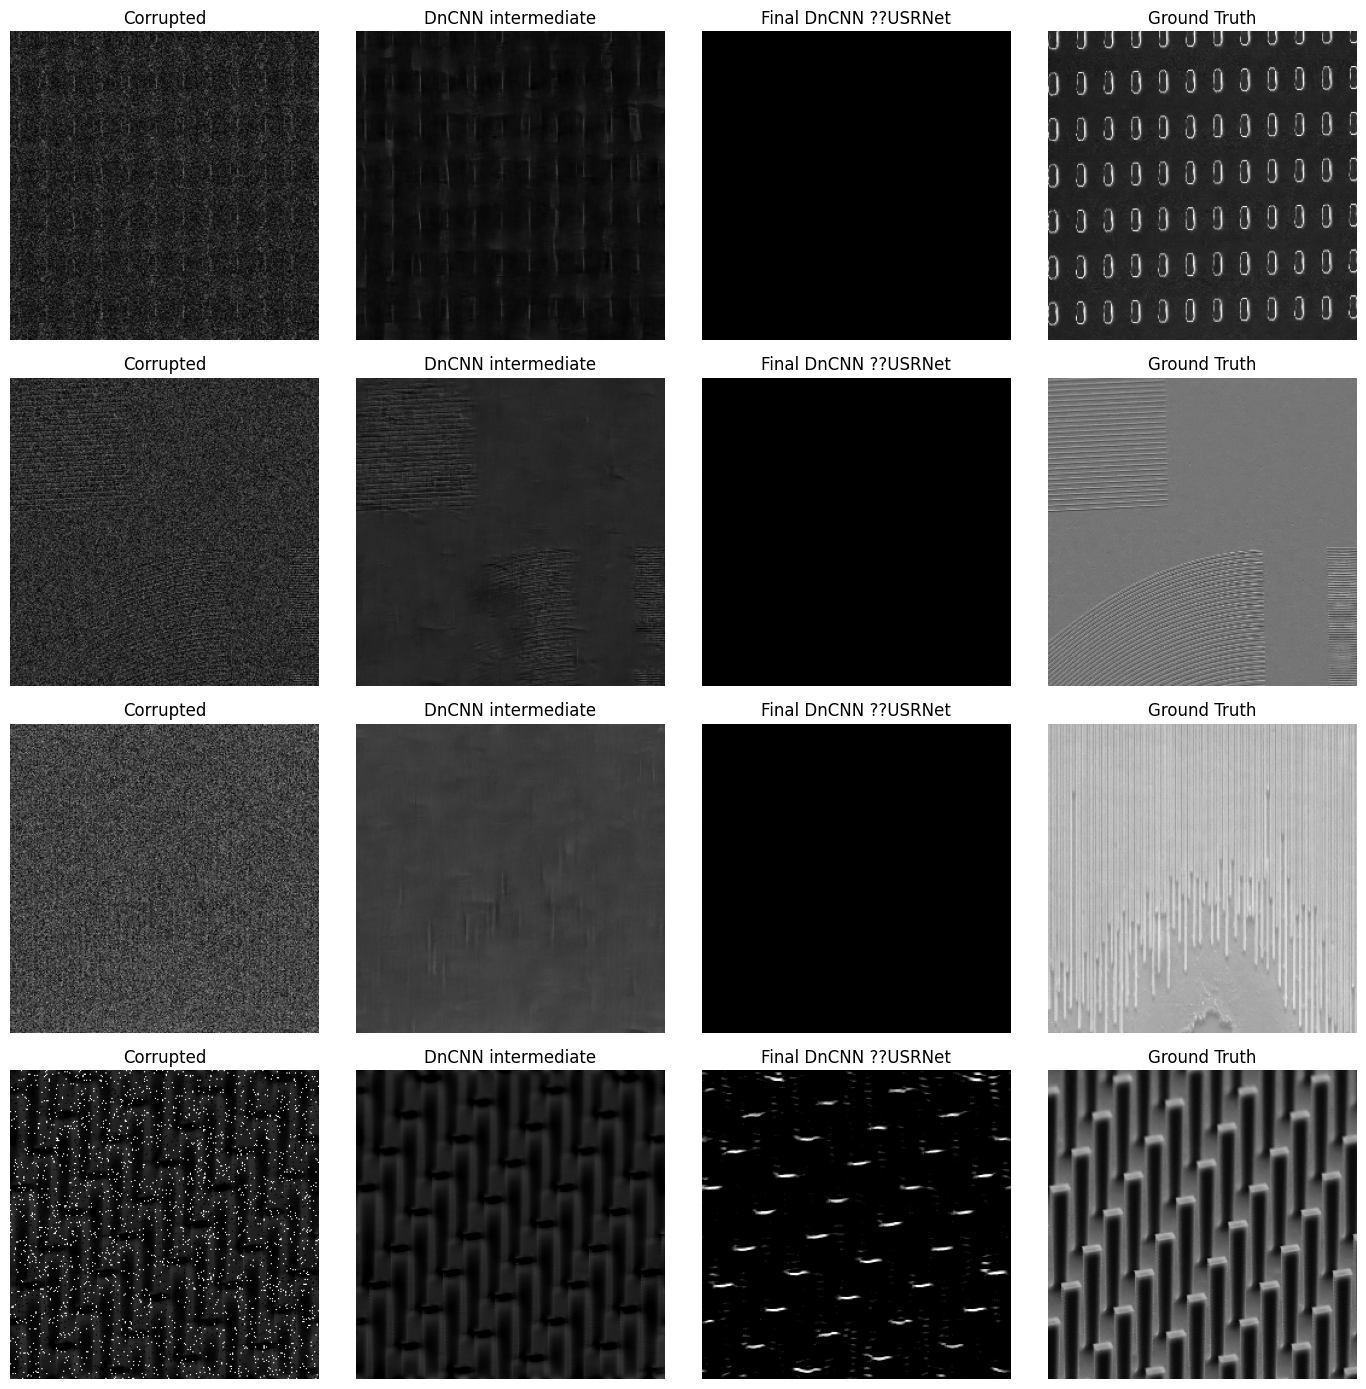

In [15]:
def score(ref,x): return peak_signal_noise_ratio(ref,np.clip(x,0,1),data_range=1),structural_similarity(ref,np.clip(x,0,1),data_range=1)
rows=[]; vis={}
for i in range(0,len(val_records),4):
    b=val_records[i:i+4]; yy,dd,kk,ss=restore_combined([r['corrupted'] for r in b])
    for r,y,d,k,s in zip(b,yy,dd,kk,ss):
        for method,x in [('Corrupted',r['corrupted']),('Final DnCNN -> USRNet',y)]:
            p,q=score(r['clean'],x); rows.append(dict(name=r['name'],noise_type=r['true_noise_type'],method=method,PSNR=p,SSIM=q))
        vis[r['name']]=(y,d,k,s)
table=pd.DataFrame(rows); per_noise=table.groupby(['noise_type','method'])[['PSNR','SSIM']].mean().round(4); overall=table.groupby('method')[['PSNR','SSIM']].mean().round(4)
display(per_noise); display(overall)
fig,ax=plt.subplots(4,4,figsize=(14,14))
for i,r in enumerate(val_records[:4]):
    y,d,k,s=vis[r['name']]
    for a,x,t in zip(ax[i],[r['corrupted'],d,y,r['clean']],['Corrupted','DnCNN intermediate','Final DnCNN ??USRNet','Ground Truth']):
        a.imshow(x,cmap='gray',vmin=0,vmax=1); a.axis('off'); a.set_title(t)
    ax[i,0].set_ylabel(f"true={r['true_noise_type']}\npred={k}\nsigma={s:.4f}")
plt.tight_layout(); plt.show()


## Hidden test inference

Only NPY images are discovered. Outputs keep the filename and use 2-D float32 arrays in [0,1].

In [16]:
test_dir=next((p for p in TEST_CANDIDATES if p.exists()),None)
if test_dir is None: raise FileNotFoundError(TEST_CANDIDATES)
test_paths=sorted(test_dir.glob('*.npy')); assert test_paths
test_predicted_counts=Counter(); test_sigmas=[]
for i in range(0,len(test_paths),4):
    pp=test_paths[i:i+4]; xx=[np.load(p).astype(np.float32).squeeze() for p in pp]; assert all(x.shape==EXPECTED_HW and np.isfinite(x).all() for x in xx)
    yy,_,kk,ss=restore_combined(xx)
    for p,y,k,s in zip(pp,yy,kk,ss): save_evaluator_npy(TEST_OUT,p.name,y,EXPECTED_HW); test_predicted_counts[k]+=1; test_sigmas.append(s)
saved=sorted(TEST_OUT.glob('*.npy')); assert len(saved)==len(test_paths)
for p in saved:
    x=np.load(p); assert x.dtype==np.float32 and x.shape==EXPECTED_HW and np.isfinite(x).all() and 0<=x.min()<=x.max()<=1
print('test output:',TEST_OUT)


test output: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_final_dncnn_usrnet/test_output


In [17]:
method='Final DnCNN -> USRNet'; avg=overall.loc[method]
print('FINAL RUN SUMMARY')
print('1. excluded validation samples:'); [print(' ',x) for x in VAL_EXCLUDE]
print('2. validation true noise type counts:',Counter(r['true_noise_type'] for r in val_records)); print('   test predicted noise type counts:',test_predicted_counts)
print(f'3. combined mean PSNR={avg.PSNR:.4f}, SSIM={avg.SSIM:.4f}')
print('4. noise type performance:'); display(per_noise.xs(method,level='method'))
print(f'5. blind classifier accuracy={classifier_accuracy:.4f}'); display(pd.DataFrame(classifier_confusion,index=NOISE_TYPES,columns=NOISE_TYPES)); print('   sigma calibration:',sigma_calibration)
print('6. test output:',TEST_OUT)
print('7. cautions: test routing/sigma are pixel-only; dipole PSF is signed/full-size/not sum-normalized; B0=(0,1), SF=1.')
print('   tensors: image [B,3,H,W], kernel [B,1,H,W], sigma [B,1,1,1]. SIGMA_MODE supports calibrated/zero.')


FINAL RUN SUMMARY
1. excluded validation samples:
  L8_f21e4564c02cffd205541f159074ad3c.npy
  L8_9312024c4ae27385406cc6c86622b65a.npy
  L8_a49c02668dabf3949344c0b795033a1f.npy
2. validation true noise type counts: Counter({'rician': 27, 'gaussian': 27, 'uniform': 26, 'salt_and_pepper': 17})
   test predicted noise type counts: Counter({np.str_('gaussian'): 41, np.str_('uniform'): 22, np.str_('rician'): 19, np.str_('salt_and_pepper'): 18})
3. combined mean PSNR=7.1020, SSIM=0.0112
4. noise type performance:


,PSNR,SSIM
noise_type,,
gaussian,6.7532,0.0178
rician,7.6532,0.0033
salt_and_pepper,6.3831,0.0113
uniform,7.3618,0.0126


5. blind classifier accuracy=0.9794


,gaussian,rician,uniform,salt_and_pepper
gaussian,26,1,0,0
rician,1,26,0,0
uniform,0,0,26,0
salt_and_pepper,0,0,0,17


   sigma calibration: {'__pooled__': (0.547243644304117, 0.014762846265402559), 'gaussian': (1.4416000998292158, 0.010129261325948408), 'rician': (0.24514361116352523, 0.033553202105225395), 'uniform': (0.6712688793478631, 0.010207419468227584), 'salt_and_pepper': (0.13108732218032795, 0.0018825296124020726)}
6. test output: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_final_dncnn_usrnet/test_output
7. cautions: test routing/sigma are pixel-only; dipole PSF is signed/full-size/not sum-normalized; B0=(0,1), SF=1.
   tensors: image [B,3,H,W], kernel [B,1,H,W], sigma [B,1,1,1]. SIGMA_MODE supports calibrated/zero.
